In [6]:
import sys, gc, json, time, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch

APP_ROOT = Path(r"C:\Users\shlok\projects\ddp-llm\comparison-search-app")
GCKL_APP = Path(r"C:\Users\shlok\projects\ddp-llm\comparison-search-app-lite-gckl\app")

for mod in list(sys.modules):
    if mod.startswith("app.") or mod == "app" or mod.startswith("gamma_ckl_engine"):
        del sys.modules[mod]

sys.path = [p for p in sys.path if "comparison-search-app-lite-gckl" not in p]
if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))
if str(GCKL_APP) not in sys.path:
    sys.path.append(str(GCKL_APP))

from app import config
from app.embeddings import Embeddings
from app.parser_llm import ParserLLM, parsed_to_y
from app.verbalizer_llm import VerbalizerLLM
from gamma_ckl_engine import GammaCKLEngine

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB", flush=True)

GAMMA = 5.0
print(f"config.MAX_QUERIES = {config.MAX_QUERIES}")
print(f"GAMMA = {GAMMA}")
print(f"parser adapter: {config.resolve_parser_adapter()}")

config.MAX_QUERIES = 50
GAMMA = 5.0
parser adapter: C:\Users\shlok\projects\ddp-llm\parser\checkpoints\qwen3b-qlora-v2\checkpoint-final


In [7]:
emb = Embeddings()
print(f"loaded {emb.n} items, dim {emb.X.shape[1]}")

TARGET_INDICES = list(range(0, emb.n, 6))
print(f"sampling {len(TARGET_INDICES)} targets (every 6th)")

BASE_SEED = 1000
def target_seed(target_idx):
    return BASE_SEED + target_idx

loaded 600 items, dim 10
sampling 100 targets (every 6th)


In [8]:
print("=" * 60)
print("PURE γ-CKL BASELINE")
print("=" * 60)

baseline_results = []
t_start = time.time()
for k, target_idx in enumerate(TARGET_INDICES):
    if k % 20 == 0:
        print(f"  {k}/{len(TARGET_INDICES)}  ({time.time()-t_start:.1f}s)", flush=True)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx),
        seed=target_seed(target_idx),
        max_queries=config.MAX_QUERIES,
    )
    while not engine.done:
        i, j = engine.propose_query()
        y = engine.oracle_answer(i, j)
        engine.apply_answer(y, status="clean")
    baseline_results.append({
        "target_idx": target_idx,
        "target_class": emb.label(target_idx),
        "steps": engine.step,
        "stop_reason": engine.stop_reason,
    })

print(f"\ndone in {time.time()-t_start:.1f}s")
steps = np.array([r["steps"] for r in baseline_results])
print(f"\nBaseline results ({len(steps)} targets):")
print(f"  mean:   {steps.mean():.1f}")
print(f"  median: {np.median(steps):.1f}")
print(f"  p95:    {np.percentile(steps, 95):.1f}")
print(f"  max:    {steps.max()}")

per_class = defaultdict(list)
for r in baseline_results:
    per_class[r["target_class"]].append(r["steps"])
print(f"\nper class:")
for cls in sorted(per_class):
    arr = np.array(per_class[cls])
    print(f"  {cls:12s}  n={len(arr)}  mean={arr.mean():.1f}  median={np.median(arr):.1f}")

PURE γ-CKL BASELINE
  0/100  (0.0s)
  20/100  (0.1s)
  40/100  (0.2s)
  60/100  (0.3s)
  80/100  (0.4s)

done in 0.5s

Baseline results (100 targets):
  mean:   13.5
  median: 11.0
  p95:    28.1
  max:    50

per class:
  buildings     n=17  mean=12.6  median=13.0
  forest        n=17  mean=13.0  median=11.0
  glacier       n=16  mean=14.9  median=12.0
  mountain      n=17  mean=14.5  median=11.0
  sea           n=17  mean=16.2  median=12.0
  street        n=16  mean=9.6  median=10.0


In [9]:
print("=" * 60)
print("SANITY CHECK — γ-CKL + verbalizer + parser, 5 targets")
print("=" * 60)

print("loading parser...")
parser = ParserLLM()
free_gpu()
print("loading verbalizer...")
verbalizer = VerbalizerLLM()
free_gpu()

sanity_targets = TARGET_INDICES[:5]
sanity_results = []
t_start = time.time()
for target_idx in sanity_targets:
    seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=config.MAX_QUERIES,
    )
    rng_lang = np.random.default_rng(seed + 999_999)
    step_log = []
    while not engine.done:
        i, j = engine.propose_query()
        y_oracle = engine.oracle_answer(i, j)
        picked = "A" if y_oracle == 0 else "B"
        utt, style = verbalizer.verbalize(picked, rng_lang, parser=parser)
        parsed, _ = parser.parse(utt, options=("A", "B"))
        y_recovered, y_status = parsed_to_y(parsed)
        if y_recovered is None:
            status = "skip"
        elif y_recovered == y_oracle:
            status = "match"
        else:
            status = "flip"
        step_log.append({
            "picked": picked, "utt": utt, "style": style,
            "y_oracle": y_oracle, "y_recovered": y_recovered, "status": status,
        })
        if status == "skip":
            engine.apply_answer(None, status="skip")
        else:
            engine.apply_answer(y_recovered, status=status)
    sanity_results.append({"target_idx": target_idx, "steps": engine.step, "step_log": step_log})
    print(f"  target {target_idx}: {engine.step} steps, "
          f"match={sum(1 for s in step_log if s['status']=='match')}, "
          f"flip={sum(1 for s in step_log if s['status']=='flip')}, "
          f"skip={sum(1 for s in step_log if s['status']=='skip')}")

print(f"\ndone in {time.time()-t_start:.1f}s")

print(f"\nsample steps from first target (idx={sanity_results[0]['target_idx']}):")
for s in sanity_results[0]["step_log"][:8]:
    print(f"  picked={s['picked']}  style={s['style']:12s}  utt={s['utt']!r:40s}  y_oracle={s['y_oracle']} y_recovered={s['y_recovered']} status={s['status']}")

del verbalizer, parser
free_gpu()

SANITY CHECK — γ-CKL + verbalizer + parser, 5 targets
loading parser...


W0930 00:38:37.161000 19828 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


VRAM: 2.18 GB
loading verbalizer...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

VRAM: 5.27 GB


C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  target 0: 9 steps, match=9, flip=0, skip=0
  target 6: 9 steps, match=9, flip=0, skip=0
  target 12: 10 steps, match=10, flip=0, skip=0
  target 18: 9 steps, match=9, flip=0, skip=0
  target 24: 17 steps, match=17, flip=0, skip=0

done in 88.7s

sample steps from first target (idx=0):
  picked=B  style=direct        utt='B for sure.'                             y_oracle=1 y_recovered=1 status=match
  picked=B  style=direct        utt='B it is.'                                y_oracle=1 y_recovered=1 status=match
  picked=A  style=positional    utt='the left one'                            y_oracle=0 y_recovered=0 status=match
  picked=B  style=casual        utt='I chose B. Left one!'                    y_oracle=1 y_recovered=1 status=match
  picked=A  style=letter        utt='A'                                       y_oracle=0 y_recovered=0 status=match
  picked=B  style=positional    utt='the right one'                           y_oracle=1 y_recovered=1 status=match
  picked=B  styl

In [10]:
print("=" * 60)
print("CLOSED-LOOP FULL RUN — γ-CKL (100 targets, in_query stopping)")
print("=" * 60)

print("loading parser...")
parser = ParserLLM()
free_gpu()
print("loading verbalizer...")
verbalizer = VerbalizerLLM()
free_gpu()

closed_loop_results = []
per_style_stats = defaultdict(lambda: {"match": 0, "skip": 0, "flip": 0, "fell_back": 0})

t_start = time.time()
for k, target_idx in enumerate(TARGET_INDICES):
    if k % 5 == 0:
        elapsed = time.time() - t_start
        eta = elapsed / (k + 1) * (len(TARGET_INDICES) - k - 1) if k > 0 else 0
        print(f"  {k}/{len(TARGET_INDICES)}  ({elapsed:.1f}s elapsed, ETA {eta:.0f}s)", flush=True)

    seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=config.MAX_QUERIES,
    )
    rng_lang = np.random.default_rng(seed + 999_999)

    step_log = []
    while not engine.done:
        i, j = engine.propose_query()
        y_oracle = engine.oracle_answer(i, j)
        picked = "A" if y_oracle == 0 else "B"

        utt, style = verbalizer.verbalize(picked, rng_lang, parser=parser)
        parsed, _ = parser.parse(utt, options=("A", "B"))
        y_recovered, y_status = parsed_to_y(parsed)

        base_style = style.replace(" (fallback)", "")
        fell_back = "(fallback)" in style
        if fell_back:
            per_style_stats[base_style]["fell_back"] += 1

        if y_recovered is None:
            status = "skip"
            per_style_stats[base_style]["skip"] += 1
        elif y_recovered == y_oracle:
            status = "match"
            per_style_stats[base_style]["match"] += 1
        else:
            status = "flip"
            per_style_stats[base_style]["flip"] += 1

        if status == "skip":
            engine.apply_answer(None, status="skip")
        else:
            engine.apply_answer(y_recovered, status=status)

        step_log.append({
            "step": engine.step, "picked": picked, "utt": utt,
            "style": style, "status": status, "y_oracle": y_oracle,
            "y_recovered": y_recovered,
        })

    closed_loop_results.append({
        "target_idx": target_idx,
        "target_class": emb.label(target_idx),
        "steps": engine.step,
        "stop_reason": engine.stop_reason,
        "step_log": step_log,
    })

t_closed = time.time() - t_start
print(f"\ndone in {t_closed:.1f}s ({t_closed/60:.1f} min)")

out_path = Path(r"C:\Users\shlok\projects\ddp-llm\scenery-search\notebooks") / "closed_loop_gckl_100.pkl"
with open(out_path, "wb") as f:
    pickle.dump({
        "baseline_results": baseline_results,
        "closed_loop_results": closed_loop_results,
        "per_style_stats": dict(per_style_stats),
        "gamma": GAMMA,
    }, f)
print(f"saved to {out_path.name}")

del verbalizer, parser
free_gpu()

CLOSED-LOOP FULL RUN — γ-CKL (100 targets, in_query stopping)
loading parser...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

VRAM: 2.19 GB
loading verbalizer...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

VRAM: 5.28 GB
  0/100  (0.0s elapsed, ETA 0s)
  5/100  (80.1s elapsed, ETA 1254s)
  10/100  (200.6s elapsed, ETA 1623s)
  15/100  (302.2s elapsed, ETA 1587s)
  20/100  (420.8s elapsed, ETA 1583s)
  25/100  (515.7s elapsed, ETA 1468s)
  30/100  (602.4s elapsed, ETA 1341s)
  35/100  (695.8s elapsed, ETA 1237s)
  40/100  (817.0s elapsed, ETA 1176s)
  45/100  (939.2s elapsed, ETA 1103s)
  50/100  (1060.0s elapsed, ETA 1018s)
  55/100  (1158.3s elapsed, ETA 910s)
  60/100  (1273.2s elapsed, ETA 814s)
  65/100  (1374.0s elapsed, ETA 708s)
  70/100  (1495.2s elapsed, ETA 611s)
  75/100  (1632.8s elapsed, ETA 516s)
  80/100  (1737.9s elapsed, ETA 408s)
  85/100  (1853.2s elapsed, ETA 302s)
  90/100  (1911.2s elapsed, ETA 189s)
  95/100  (1994.6s elapsed, ETA 83s)

done in 2057.3s (34.3 min)
saved to closed_loop_gckl_100.pkl
VRAM: 0.01 GB


In [11]:
print("=" * 70)
print("γ-CKL CLOSED-LOOP RESULTS (100 targets, in_query stopping)")
print("=" * 70)

steps_baseline = np.array([r["steps"] for r in baseline_results])
steps_closed = np.array([r["steps"] for r in closed_loop_results])

print(f"\n{'metric':<15s} {'γ-CKL baseline':<16s} {'γ-CKL closed':<14s} {'delta':<10s}")
print("-" * 60)
for name, fn in [("mean", np.mean), ("median", np.median),
                  ("p95", lambda x: np.percentile(x, 95)),
                  ("max", np.max)]:
    b = fn(steps_baseline)
    c = fn(steps_closed)
    print(f"{name:<15s} {b:<16.1f} {c:<14.1f} {c-b:+.1f}")

total_steps = sum(len(r["step_log"]) for r in closed_loop_results)
n_match = sum(1 for r in closed_loop_results for s in r["step_log"] if s["status"] == "match")
n_flip = sum(1 for r in closed_loop_results for s in r["step_log"] if s["status"] == "flip")
n_skip = sum(1 for r in closed_loop_results for s in r["step_log"] if s["status"] == "skip")

print(f"\nround-trip fidelity across all {total_steps} steps:")
print(f"  match:  {n_match:4d}  ({100*n_match/total_steps:.1f}%)")
print(f"  flip:   {n_flip:4d}  ({100*n_flip/total_steps:.1f}%)")
print(f"  skip:   {n_skip:4d}  ({100*n_skip/total_steps:.1f}%)")

print(f"\nper-style breakdown:")
print(f"  {'style':<12s} {'match':<8s} {'flip':<8s} {'skip':<8s} {'fell_back':<10s} {'match%':<8s}")
print("-" * 60)
for style_name in ["letter", "ordinal", "positional", "direct", "casual"]:
    if style_name not in per_style_stats:
        continue
    s = per_style_stats[style_name]
    n = s["match"] + s["flip"] + s["skip"]
    match_pct = 100 * s["match"] / n if n > 0 else 0
    print(f"  {style_name:<12s} {s['match']:<8d} {s['flip']:<8d} {s['skip']:<8d} {s['fell_back']:<10d} {match_pct:.1f}%")

per_class_b = defaultdict(list)
per_class_c = defaultdict(list)
for r in baseline_results:
    per_class_b[r["target_class"]].append(r["steps"])
for r in closed_loop_results:
    per_class_c[r["target_class"]].append(r["steps"])

print(f"\nper-class comparison:")
print(f"  {'class':<12s} {'baseline':<12s} {'closed':<12s} {'delta':<10s}")
print("-" * 50)
for cls in sorted(per_class_b):
    b = np.mean(per_class_b[cls])
    c = np.mean(per_class_c[cls])
    print(f"  {cls:<12s} {b:<12.1f} {c:<12.1f} {c-b:+.1f}")

print(f"\n\n=== γ-CKL vs GAUSS (both closed-loop, from prior work) ===")
print(f"                  {'GAUSS closed':<14s} {'γ-CKL closed':<14s}")
print(f"mean queries:     {'15.1':<14s} {steps_closed.mean():<14.1f}")
print(f"round-trip match: {'100.0%':<14s} {100*n_match/total_steps:<13.1f}%")

γ-CKL CLOSED-LOOP RESULTS (100 targets, in_query stopping)

metric          γ-CKL baseline   γ-CKL closed   delta     
------------------------------------------------------------
mean            13.5             13.5           +0.0
median          11.0             11.0           +0.0
p95             28.1             28.1           +0.0
max             50.0             50.0           +0.0

round-trip fidelity across all 1348 steps:
  match:  1348  (100.0%)
  flip:      0  (0.0%)
  skip:      0  (0.0%)

per-style breakdown:
  style        match    flip     skip     fell_back  match%  
------------------------------------------------------------
  letter       266      0        0        8          100.0%
  ordinal      285      0        0        0          100.0%
  positional   268      0        0        0          100.0%
  direct       259      0        0        0          100.0%
  casual       270      0        0        0          100.0%

per-class comparison:
  class        baseline  

In [12]:
unconverged = [r for r in closed_loop_results if r["stop_reason"] != "in_query"]
print(f"unconverged: {len(unconverged)}")
for r in unconverged:
    print(f"  target {r['target_idx']} ({r['target_class']}): {r['steps']} steps, stop_reason={r['stop_reason']}")

unconverged: 1
  target 444 (sea): 50 steps, stop_reason=max_queries


In [13]:
def inspect_target(target_idx, results=closed_loop_results, emb=emb):
    r = next((x for x in results if x["target_idx"] == target_idx), None)
    if r is None:
        print(f"target {target_idx} not in results")
        return
    print(f"target_idx = {target_idx}")
    print(f"target class = {r['target_class']}")
    print(f"total steps = {r['steps']}")
    print(f"stop_reason = {r['stop_reason']}")
    print()

    seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=config.MAX_QUERIES,
    )
    print(f"{'step':<5} {'i':<5} {'class_i':<12} {'j':<5} {'class_j':<12} {'picked':<7} {'style':<12} {'utt'}")
    print("-" * 110)
    for step_log in r["step_log"]:
        i, j = engine.propose_query()
        cls_i = emb.label(i)
        cls_j = emb.label(j)
        picked_idx = i if step_log["y_oracle"] == 0 else j
        picked_cls = emb.label(picked_idx)
        marker_i = "★" if i == target_idx else ("→" if picked_idx == i else " ")
        marker_j = "★" if j == target_idx else ("→" if picked_idx == j else " ")
        print(f"{step_log['step']:<5} "
              f"{i:<4}{marker_i} {cls_i:<12} "
              f"{j:<4}{marker_j} {cls_j:<12} "
              f"{step_log['picked']:<7} {step_log['style']:<12} {step_log['utt']!r}")
        engine.apply_answer(step_log["y_oracle"], status="clean")

    print(f"\n★ = target, → = picked")

# examples:
inspect_target(444)   # the unconverged sea target

target_idx = 444
target class = sea
total steps = 50
stop_reason = max_queries

step  i     class_i      j     class_j      picked  style        utt
--------------------------------------------------------------------------------------------------------------
1     371 → mountain     69    buildings    A       direct       'Option A.'
2     261 → glacier      121   forest       A       positional   'the left one'
3     290   glacier      359 → mountain     B       letter       'B'
4     211   glacier      475 → sea          B       ordinal      'the second one'
5     309 → mountain     467   sea          A       direct       "I'll take Option A."
6     398 → mountain     312   mountain     A       direct       "I'll go with A."
7     329 → mountain     361   mountain     A       direct       "I'll take Option A."
8     327 → mountain     322   mountain     A       casual       'I chose A. Left one.'
9     376 → mountain     330   mountain     A       ordinal      'the first one'
10    

In [14]:
inspect_target(0)     # target that finished in 9 steps
inspect_target(24)    # target that took 17 steps

target_idx = 0
target class = buildings
total steps = 9
stop_reason = in_query

step  i     class_i      j     class_j      picked  style        utt
--------------------------------------------------------------------------------------------------------------
1     371   mountain     69  → buildings    B       direct       'B for sure.'
2     177   forest       45  → buildings    B       direct       'B it is.'
3     46  → buildings    591   street       A       positional   'the left one'
4     84    buildings    534 → street       B       casual       'I chose B. Left one!'
5     595 → street       14    buildings    A       letter       'A'
6     81    buildings    562 → street       B       positional   'the right one'
7     573   street       4   → buildings    B       direct       'B it is.'
8     580   street       581 → street       B       ordinal      'the second one'
9     0   ★ buildings    50    buildings    A       letter       'A'

★ = target, → = picked
target_idx = 24


In [16]:
inspect_target(402) 

target_idx = 402
target class = sea
total steps = 7
stop_reason = in_query

step  i     class_i      j     class_j      picked  style        utt
--------------------------------------------------------------------------------------------------------------
1     371 → mountain     69    buildings    A       casual       'Got it on A. Right one!'
2     261   glacier      121 → forest       B       ordinal      'the second one'
3     189   forest       414 → sea          B       letter       'B'
4     441 → sea          312   mountain     A       letter       'A'
5     493 → sea          258   glacier      A       casual       'Got it! First one.'
6     420   sea          409 → sea          B       direct       'B it is.'
7     402 ★ sea          486   sea          A       positional   'the left one'

★ = target, → = picked


In [17]:
target_idx = 444
x_t = emb.X[target_idx]
dists = np.linalg.norm(emb.X - x_t, axis=1)
labels_arr = np.array(emb.labels if hasattr(emb, 'labels') else [emb.label(i) for i in range(emb.n)])

nearest = np.argsort(dists)[1:11]
print(f"target 444 ({emb.label(444)}) — 10 nearest neighbors in embedding:")
for idx in nearest:
    print(f"  idx={idx:4d}  class={emb.label(idx):12s}  dist={dists[idx]:.3f}")

for cls in sorted(set(emb.label(i) for i in range(emb.n))):
    cls_dists = dists[[i for i in range(emb.n) if emb.label(i) == cls and i != target_idx]]
    print(f"  class {cls:12s}  mean_dist={cls_dists.mean():.3f}  min_dist={cls_dists.min():.3f}")

target 444 (sea) — 10 nearest neighbors in embedding:
  idx= 491  class=sea           dist=1.562
  idx= 401  class=sea           dist=1.726
  idx= 486  class=sea           dist=1.733
  idx= 467  class=sea           dist=1.843
  idx= 458  class=sea           dist=1.902
  idx= 425  class=sea           dist=1.951
  idx= 499  class=sea           dist=2.028
  idx= 464  class=sea           dist=2.052
  idx= 496  class=sea           dist=2.105
  idx= 474  class=sea           dist=2.109
  class buildings     mean_dist=5.280  min_dist=3.376
  class forest        mean_dist=5.311  min_dist=3.349
  class glacier       mean_dist=5.206  min_dist=3.374
  class mountain      mean_dist=4.939  min_dist=3.618
  class sea           mean_dist=2.932  min_dist=1.562
  class street        mean_dist=4.847  min_dist=2.981


In [18]:
target_idx = 444
x_t = emb.X[target_idx]

sea_indices = [i for i in range(emb.n) if emb.label(i) == "sea" and i != target_idx]
sea_dists = np.linalg.norm(emb.X[sea_indices] - x_t, axis=1)

from itertools import combinations
n_sample = 200
rng = np.random.default_rng(0)
sampled = rng.choice(sea_indices, size=(n_sample, 2), replace=True)

confidences = []
for i, j in sampled:
    if i == j: continue
    d_i = np.linalg.norm(emb.X[i] - x_t)
    d_j = np.linalg.norm(emb.X[j] - x_t)
    p = (d_j ** GAMMA) / (d_i ** GAMMA + d_j ** GAMMA)
    confidences.append(max(p, 1-p))

confidences = np.array(confidences)
print(f"target 444: sea-vs-sea query confidence")
print(f"  mean: {confidences.mean():.3f}")
print(f"  median: {np.median(confidences):.3f}")
print(f"  fraction >0.9: {(confidences > 0.9).mean():.2f}")
print(f"  fraction <0.6: {(confidences < 0.6).mean():.2f}")

target 444: sea-vs-sea query confidence
  mean: 0.739
  median: 0.745
  fraction >0.9: 0.16
  fraction <0.6: 0.21


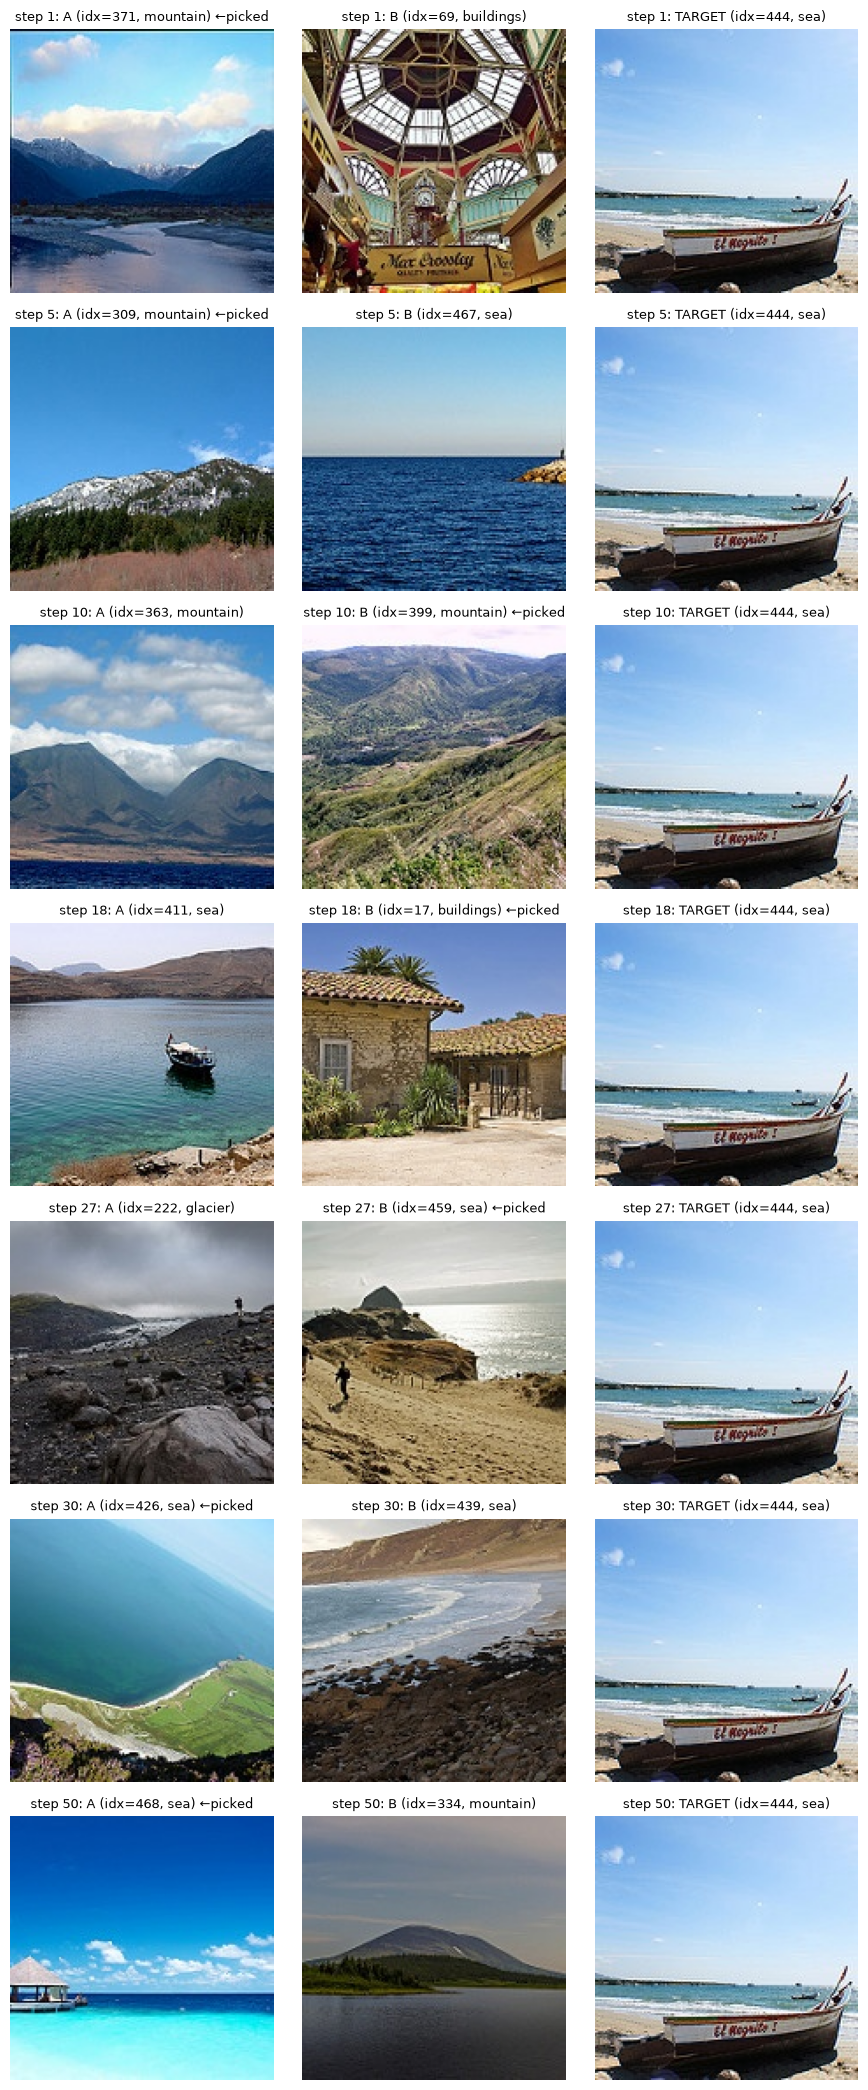

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

def show_target_and_queries(target_idx, step_indices, results=closed_loop_results, emb=emb):
    r = next((x for x in results if x["target_idx"] == target_idx), None)
    if r is None:
        print(f"target {target_idx} not in results")
        return

    seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=config.MAX_QUERIES,
    )
    trajectory = []
    for step_log in r["step_log"]:
        i, j = engine.propose_query()
        trajectory.append((i, j, step_log["y_oracle"]))
        engine.apply_answer(step_log["y_oracle"], status="clean")

    n = len(step_indices)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, step_num in enumerate(step_indices):
        i, j, y = trajectory[step_num - 1]
        picked_idx = i if y == 0 else j
        target_path = emb.paths[target_idx]
        i_path = emb.paths[i]
        j_path = emb.paths[j]

        for col, (idx, path, title_prefix) in enumerate([
            (i, i_path, f"A (idx={i}, {emb.label(i)})"),
            (j, j_path, f"B (idx={j}, {emb.label(j)})"),
            (target_idx, target_path, f"TARGET (idx={target_idx}, {emb.label(target_idx)})"),
        ]):
            ax = axes[row, col]
            try:
                img = Image.open(path)
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, f"err: {e}", ha='center', va='center')
            picked_marker = " ←picked" if idx == picked_idx and col < 2 else ""
            ax.set_title(f"step {step_num}: {title_prefix}{picked_marker}", fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

show_target_and_queries(444, [1, 5, 10, 18, 27, 30, 50])

In [20]:
target_idx = 444
x_t = emb.X[target_idx]
d_309 = np.linalg.norm(emb.X[309] - x_t)
d_467 = np.linalg.norm(emb.X[467] - x_t)
print(f"target 444 (sea)")
print(f"  distance to 309 (mountain): {d_309:.3f}")
print(f"  distance to 467 (sea):      {d_467:.3f}")
print(f"  P(pick 309) under γ=5: {(d_467**5)/(d_309**5 + d_467**5):.3f}")

target 444 (sea)
  distance to 309 (mountain): 5.384
  distance to 467 (sea):      1.843
  P(pick 309) under γ=5: 0.005


In [21]:
target_idx = 444
seed = target_seed(target_idx)
engine = GammaCKLEngine(
    X=emb.X, gamma=GAMMA,
    target_idx=int(target_idx), seed=seed,
    max_queries=config.MAX_QUERIES,
)

r = next(x for x in closed_loop_results if x["target_idx"] == target_idx)

for step_idx, step_log in enumerate(r["step_log"][:6]):
    i, j = engine.propose_query()
    y_fresh = engine.oracle_answer(i, j)
    y_recorded = step_log["y_oracle"]
    match = "✓" if y_fresh == y_recorded else "✗ DRIFT"
    print(f"step {step_idx+1}: i={i} j={j} y_fresh={y_fresh} y_recorded={y_recorded} {match}")
    engine.apply_answer(y_recorded, status="clean")

step 1: i=371 j=69 y_fresh=0 y_recorded=0 ✓
step 2: i=261 j=121 y_fresh=0 y_recorded=0 ✓
step 3: i=290 j=359 y_fresh=1 y_recorded=1 ✓
step 4: i=211 j=475 y_fresh=1 y_recorded=1 ✓
step 5: i=309 j=467 y_fresh=0 y_recorded=0 ✓
step 6: i=398 j=312 y_fresh=0 y_recorded=0 ✓


In [22]:
def adversarial_oracle(engine, i, j, corruption_steps):
    y_normal = engine.oracle_answer(i, j)
    if engine.step < corruption_steps:
        return 1 - y_normal
    return y_normal

def run_adversarial(target_idx, corruption_steps, seed=None):
    if seed is None:
        seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=100,
    )
    log = []
    while not engine.done:
        i, j = engine.propose_query()
        y = adversarial_oracle(engine, i, j, corruption_steps)
        is_adversarial = engine.step < corruption_steps
        log.append({
            "step": engine.step + 1, "i": i, "j": j,
            "class_i": emb.label(i), "class_j": emb.label(j),
            "y": y, "adversarial": is_adversarial,
        })
        engine.apply_answer(y, status="clean")
    return {
        "target_idx": target_idx,
        "target_class": emb.label(target_idx),
        "steps": engine.step,
        "stop_reason": engine.stop_reason,
        "corruption_steps": corruption_steps,
        "log": log,
    }

print("=" * 70)
print("ADVERSARIAL ROBUSTNESS — mislead for X queries, then correct")
print("=" * 70)

TEST_TARGETS = [0, 24, 402, 444]
CORRUPTION_LEVELS = [0, 2, 5, 10, 15]

print(f"\n{'target':<10} {'class':<10}", end="")
for x in CORRUPTION_LEVELS:
    print(f"  X={x:<4}", end="")
print()
print("-" * 60)

for target_idx in TEST_TARGETS:
    print(f"{target_idx:<10} {emb.label(target_idx):<10}", end="")
    for x in CORRUPTION_LEVELS:
        r = run_adversarial(target_idx, x)
        marker = "*" if r["stop_reason"] == "max_queries" else " "
        print(f"  {r['steps']:>3}{marker} ", end="")
    print()

print("\n* = hit max_queries (100), did not converge")

ADVERSARIAL ROBUSTNESS — mislead for X queries, then correct

target     class       X=0     X=2     X=5     X=10    X=15  
------------------------------------------------------------
0          buildings     9     32     28     32     67  
24         buildings    17     28     35     26     56  
402        sea           7     32     67     35     50  
444        sea          56     10     50     33     50  

* = hit max_queries (100), did not converge


In [23]:
target_idx = 402
CORRUPTION = 5
r = run_adversarial(target_idx, CORRUPTION)
print(f"\ntarget {target_idx} ({r['target_class']}), corruption for {CORRUPTION} steps, total {r['steps']} steps")
print(f"stop_reason: {r['stop_reason']}\n")
print(f"{'step':<5} {'adv?':<6} {'i':<5} {'class_i':<12} {'j':<5} {'class_j':<12} {'y':<3} {'picked_class':<12}")
print("-" * 80)
for s in r["log"]:
    picked = s["class_j"] if s["y"] == 1 else s["class_i"]
    adv_mark = "ADV" if s["adversarial"] else "  ."
    print(f"{s['step']:<5} {adv_mark:<6} {s['i']:<5} {s['class_i']:<12} {s['j']:<5} {s['class_j']:<12} {s['y']:<3} {picked:<12}")


target 402 (sea), corruption for 5 steps, total 67 steps
stop_reason: in_query

step  adv?   i     class_i      j     class_j      y   picked_class
--------------------------------------------------------------------------------
1     ADV    371   mountain     69    buildings    1   buildings   
2     ADV    177   forest       45    buildings    1   buildings   
3     ADV    46    buildings    591   street       0   buildings   
4     ADV    84    buildings    534   street       1   street      
5     ADV    595   street       14    buildings    1   buildings   
6       .    44    buildings    21    buildings    1   buildings   
7       .    538   street       99    buildings    1   buildings   
8       .    65    buildings    28    buildings    0   buildings   
9       .    539   street       592   street       0   street      
10      .    79    buildings    50    buildings    0   buildings   
11      .    87    buildings    587   street       0   buildings   
12      .    96    bui

In [41]:
def run_baseline(target_idx, corruption_steps, seed=None):
    if seed is None:
        seed = target_seed(target_idx)
    engine = GammaCKLEngine(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=100,
    )
    while not engine.done:
        i, j = engine.propose_query()
        y_normal = engine.oracle_answer(i, j)
        y = (1 - y_normal) if engine.step < corruption_steps else y_normal
        engine.apply_answer(y, status="clean")
    return engine.step, engine.stop_reason

def compare_table(runners, labels, targets=[0, 24, 402, 444], levels=[0, 2, 5, 10, 15]):
    print(f"{'target':<8} {'class':<10} {'method':<20}", end="")
    for x in levels:
        print(f"  X={x:<4}", end="")
    print()
    print("-" * (40 + 8*len(levels)))
    for target_idx in targets:
        for runner, label in zip(runners, labels):
            print(f"{target_idx:<8} {emb.label(target_idx):<10} {label:<20}", end="")
            for x in levels:
                steps, reason = runner(target_idx, x)
                marker = "*" if reason == "max_queries" else " "
                print(f"  {steps:>3}{marker} ", end="")
            print()
        print()

In [42]:
class GammaCKLEngineDivers(GammaCKLEngine):
    def __init__(self, *args, divers_weight=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        self.divers_weight = divers_weight

    def propose_query(self):
        if self._pending_query is not None:
            return self._pending_query
        eps = 1e-12
        mu = (self.P[:, None] * self.X).sum(axis=0)
        diff = self.X - mu
        Sigma = (self.P[:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0)
        eigvals, eigvecs = np.linalg.eigh(Sigma)
        lam_max = max(eigvals[-1], eps)
        v_max = eigvecs[:, -1]
        z1 = mu + self.r * np.sqrt(lam_max) * v_max
        z2 = mu - self.r * np.sqrt(lam_max) * v_max

        if len(self.used) > 0:
            used_arr = np.array(list(self.used))
            X_used = self.X[used_arr]
            min_dist_to_used = np.min(
                np.linalg.norm(self.X[:, None, :] - X_used[None, :, :], axis=2),
                axis=1
            )
        else:
            min_dist_to_used = np.ones(self.n)

        def score(z, excl):
            d2 = np.sum((self.X - z) ** 2, axis=1)
            base = d2 / (self.P + eps)
            penalty = self.divers_weight / (min_dist_to_used + eps)
            s = base + penalty
            for u in excl:
                s[u] = np.inf
            return int(np.argmin(s))

        i = score(z1, self.used)
        j = score(z2, self.used | {i})
        self._pending_query = (i, j)
        return i, j

def run_divers(target_idx, corruption_steps, seed=None):
    if seed is None:
        seed = target_seed(target_idx)
    engine = GammaCKLEngineDivers(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=100, divers_weight=0.5,
    )
    while not engine.done:
        i, j = engine.propose_query()
        y_normal = engine.oracle_answer(i, j)
        y = (1 - y_normal) if engine.step < corruption_steps else y_normal
        engine.apply_answer(y, status="clean")
    return engine.step, engine.stop_reason

In [43]:
class GammaCKLEngineRestart(GammaCKLEngine):
    def __init__(self, *args, restart_after=20, restart_top_frac=0.02, **kwargs):
        super().__init__(*args, **kwargs)
        self.restart_after = restart_after
        self.restart_top_frac = restart_top_frac
        self.n_restarts = 0
        self.last_restart_step = 0

    def apply_answer(self, y, status="clean"):
        record = super().apply_answer(y, status=status)
        if self.done:
            return record
        if self.step - self.last_restart_step >= self.restart_after:
            k = max(1, int(self.n * self.restart_top_frac))
            top_k_idx = np.argsort(-self.P)[:k]
            new_P = np.ones(self.n) / self.n
            for u in self.used:
                new_P[u] = 0
            if new_P.sum() > 0:
                new_P = new_P / new_P.sum()
                self.P = new_P
                self.n_restarts += 1
                self.last_restart_step = self.step
        return record

def run_restart(target_idx, corruption_steps, seed=None):
    if seed is None:
        seed = target_seed(target_idx)
    engine = GammaCKLEngineRestart(
        X=emb.X, gamma=GAMMA,
        target_idx=int(target_idx), seed=seed,
        max_queries=100, restart_after=20,
    )
    while not engine.done:
        i, j = engine.propose_query()
        y_normal = engine.oracle_answer(i, j)
        y = (1 - y_normal) if engine.step < corruption_steps else y_normal
        engine.apply_answer(y, status="clean")
    return engine.step, engine.stop_reason

In [44]:
compare_table(
    [run_baseline, run_divers, run_restart],
    ["baseline γ-CKL", "diversification", "restart every 20"],
)

target   class      method                X=0     X=2     X=5     X=10    X=15  
--------------------------------------------------------------------------------
0        buildings  baseline γ-CKL          9     32     28     32     67  
0        buildings  diversification         9     32     28     32     67  
0        buildings  restart every 20        9     31     30     31     34  

24       buildings  baseline γ-CKL         17     28     35     26     56  
24       buildings  diversification        17     28     35     26     56  
24       buildings  restart every 20       17     31     32     32     31  

402      sea        baseline γ-CKL          7     32     67     35     50  
402      sea        diversification         7     32     67     35     50  
402      sea        restart every 20        7     36     32     34     30  

444      sea        baseline γ-CKL         56     10     50     33     50  
444      sea        diversification        56     10     50     33     50  

In [45]:
print("\n\n=== 100-TARGET AGGREGATE ===\n")

runners = {"baseline": run_baseline, "restart-20": run_restart}
CORRUPTIONS = [0, 5, 10]

for x in CORRUPTIONS:
    print(f"\nCorruption X={x}:")
    print(f"  {'method':<18} {'mean':<8} {'median':<8} {'p95':<8} {'max':<6} {'unconv':<8}")
    print("  " + "-" * 55)
    for name, runner in runners.items():
        steps_list = []
        n_unconverged = 0
        for target_idx in TARGET_INDICES:
            steps, reason = runner(target_idx, x)
            steps_list.append(steps)
            if reason == "max_queries":
                n_unconverged += 1
        arr = np.array(steps_list)
        print(f"  {name:<18} {arr.mean():<8.1f} {np.median(arr):<8.1f} "
              f"{np.percentile(arr, 95):<8.1f} {arr.max():<6d} {n_unconverged}/100")



=== 100-TARGET AGGREGATE ===


Corruption X=0:
  method             mean     median   p95      max    unconv  
  -------------------------------------------------------
  baseline           13.5     11.0     28.1     56     0/100
  restart-20         14.3     11.0     31.0     68     0/100

Corruption X=5:
  method             mean     median   p95      max    unconv  
  -------------------------------------------------------
  baseline           36.7     35.0     55.1     69     0/100
  restart-20         32.5     31.0     52.2     69     0/100

Corruption X=10:
  method             mean     median   p95      max    unconv  
  -------------------------------------------------------
  baseline           38.5     38.0     58.1     84     0/100
  restart-20         32.6     31.0     53.0     74     0/100


In [38]:
import pickle
robustness_final = {
    "TARGET_INDICES": TARGET_INDICES,
    "gamma": GAMMA,
    "results": {
        "baseline": {x: [run_baseline(t, x) for t in TARGET_INDICES] for x in [0, 5, 10]},
        "restart_20": {x: [run_restart(t, x) for t in TARGET_INDICES] for x in [0, 5, 10]},
    },
    "notes": "Periodic restart every 20 queries with ban list. Baseline is stock gamma-CKL algorithm 3. Adversarial corruption = flip oracle answer for first X queries.",
}
with open(r"C:\Users\shlok\projects\ddp-llm\scenery-search\notebooks\robustness_100.pkl", "wb") as f:
    pickle.dump(robustness_final, f)
print("saved robustness_100.pkl")

saved robustness_100.pkl
